# Programming assignment 1: Introduction to ML workflow and decision trees 

Names: Sergi Cases & Martí Pascual

First we do all the necessary imports

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from abc import ABC, abstractmethod
from collections import Counter
from graphviz import Digraph

### Task 1: A classification example: fetal heart condition diagnosis

In [28]:
# step 1: Load and prepare the data 

data = pd.read_csv("CTG.csv", skiprows=1)

selected_cols = [
    'LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
    'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
    'Median', 'Variance', 'Tendency', 'NSP'
]
data = data[selected_cols].dropna()

# Shuffle the dataset 
data_shuffled = data.sample(frac=1.0, random_state=0)

# split into features (X) and target label (Y)
X = data_shuffled.drop('NSP', axis=1)

def to_label(y):
    return [None, 'normal', 'suspect', 'pathologic'][int(y)]

Y = data_shuffled['NSP'].apply(to_label)

# and then do the splits
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)

We can visualize the number of samples and also take a peek to the data

In [29]:
print(f"Training samples : {len(Xtrain)}")
print(f"Test samples     : {len(Xtest)}")
print(f"\nClass distribution:\n{Y.value_counts()}")
X.head()

Training samples : 1700
Test samples     : 426

Class distribution:
NSP
normal        1655
suspect        295
pathologic     176
Name: count, dtype: int64


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
658,130.0,1.0,0.0,3.0,0.0,0.0,0.0,24.0,1.2,12.0,...,35.0,120.0,155.0,1.0,0.0,134.0,133.0,135.0,1.0,0.0
1734,134.0,9.0,1.0,8.0,5.0,0.0,0.0,59.0,1.2,0.0,...,109.0,80.0,189.0,6.0,0.0,150.0,146.0,150.0,33.0,0.0
1226,125.0,1.0,0.0,4.0,0.0,0.0,0.0,43.0,0.7,31.0,...,21.0,120.0,141.0,0.0,0.0,131.0,130.0,132.0,1.0,0.0
1808,143.0,0.0,0.0,1.0,0.0,0.0,0.0,69.0,0.3,6.0,...,27.0,132.0,159.0,1.0,0.0,145.0,144.0,146.0,1.0,0.0
825,152.0,0.0,0.0,4.0,0.0,0.0,0.0,62.0,0.4,59.0,...,25.0,136.0,161.0,0.0,0.0,159.0,156.0,158.0,1.0,1.0


In [30]:
# Step 2: Training the baseline classifier
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy_clf, Xtrain, Ytrain, cv=5)

print(f"Dummy classifier-->DCV accuracy: {dummy_scores.mean():.4f} ± {dummy_scores.std():.4f}")

Dummy classifier-->DCV accuracy: 0.7806 ± 0.0014


We take the mean and also take into account the standard deviation. We get accuracy = 0.7806 ± 0.0014

In [31]:
#Step 3. Trying out some different classifiers

classifiers = {
    "Decision Tree"    : DecisionTreeClassifier(random_state=0),
    "Decision Tree with max_depth=5": DecisionTreeClassifier(max_depth=5, random_state=0),
    "Random Forest"              : RandomForestClassifier(n_estimators=200, random_state=0),
    "Gradient Boosting"          : GradientBoostingClassifier(n_estimators=100, random_state=0),
}

results = {}
for name, clf in classifiers.items():
    scores = cross_val_score(clf, Xtrain, Ytrain, cv=5)
    results[name] = scores
    print(f"{name:<35} CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Decision Tree                       CV accuracy: 0.9241 ± 0.0167
Decision Tree with max_depth=5      CV accuracy: 0.9282 ± 0.0141
Random Forest                       CV accuracy: 0.9418 ± 0.0073
Gradient Boosting                   CV accuracy: 0.9500 ± 0.0067


We decided to go with 3 of the most common classifiers: decision trees, random forest and finally Gradient boosting.

After testing the  different classifiers and also tuning the hyperparameters several times, we get that the best one of them is Gradient Boosting with 100 estimators, with an accuracy of 0.9500.

In [32]:
# Step 4. Final evaluation
best_clf = GradientBoostingClassifier(n_estimators=100, random_state=0)

best_clf.fit(Xtrain, Ytrain)
Yguess = best_clf.predict(Xtest)
test_accuracy = accuracy_score(Ytest, Yguess)

print(f"Gradient Boosting- -> Test set accuracy: {test_accuracy:.4f}")

Gradient Boosting- -> Test set accuracy: 0.9296


After testing the classifier on the validation set we get an accuracy of 0.9296, which is quite high. The slight gap between CV and test accuracy, suggests a minimal overfit, but in our opinion it is not significant.

### Task 2: Decision trees for classification

The code below is from the notebook provided

In [33]:
class DecisionTreeLeaf:

    def __init__(self, value):
        self.value = value

    def predict(self, x):
        return self.value

    def draw_tree(self, graph, node_counter, names):
        node_id = str(node_counter)
        val_str = f'{self.value:.4g}' if isinstance(self.value, float) else str(self.value)
        graph.node(node_id, val_str, style='filled')
        return node_counter + 1, node_id

    def __eq__(self, other):
        if isinstance(other, DecisionTreeLeaf):
            return self.value == other.value
        return False


class DecisionTreeBranch:

    def __init__(self, feature, threshold, low_subtree, high_subtree):
        self.feature = feature
        self.threshold = threshold
        self.low_subtree = low_subtree
        self.high_subtree = high_subtree

    def predict(self, x):
        if x[self.feature] <= self.threshold:
            return self.low_subtree.predict(x)
        else:
            return self.high_subtree.predict(x)

    def draw_tree(self, graph, node_counter, names):
        node_counter, low_id  = self.low_subtree.draw_tree(graph, node_counter, names)
        node_counter, high_id = self.high_subtree.draw_tree(graph, node_counter, names)
        node_id = str(node_counter)
        fname = f'F{self.feature}' if names is None else names[self.feature]
        lbl = f'{fname} > {self.threshold:.4g}?'
        graph.node(node_id, lbl, shape='box', fillcolor='yellow', style='filled, rounded')
        graph.edge(node_id, low_id,  'False')
        graph.edge(node_id, high_id, 'True')
        return node_counter + 1, node_id


def majority_sum_scorer(n_low, low_distr, n_high, high_distr):
    return low_distr.most_common(1)[0][1] + high_distr.most_common(1)[0][1]

def entropy(distr):
    n  = sum(distr.values())
    ps = [n_i / n for n_i in distr.values()]
    return -sum(p * np.log2(p) if p > 0 else 0 for p in ps)

def info_gain_scorer(n_low, low_distr, n_high, high_distr):
    return -(n_low * entropy(low_distr) + n_high * entropy(high_distr)) / (n_low + n_high)

def gini_impurity(distr):
    n  = sum(distr.values())
    ps = [n_i / n for n_i in distr.values()]
    return 1 - sum(p ** 2 for p in ps)

def gini_scorer(n_low, low_distr, n_high, high_distr):
    return -(n_low * gini_impurity(low_distr) + n_high * gini_impurity(high_distr)) / (n_low + n_high)


class DecisionTree(ABC, BaseEstimator):

    def __init__(self, max_depth):
        super().__init__()
        self.max_depth = max_depth

    def fit(self, X, Y):
        if isinstance(X, pd.DataFrame):
            self.names = list(X.columns)
            X = X.to_numpy()
        elif isinstance(X, list):
            self.names = None
            X = np.array(X)
        else:
            self.names = None
        Y = np.array(Y)
        self.root = self.make_tree(X, Y, self.max_depth)

    def draw_tree(self):
        graph = Digraph()
        self.root.draw_tree(graph, 0, self.names)
        return graph

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        return [self.predict_one(x) for x in X]

    def predict_one(self, x):
        return self.root.predict(x)

    def make_tree(self, X, Y, max_depth):
        default_value = self.get_default_value(Y)

        if max_depth == 0:
            return DecisionTreeLeaf(default_value)

        if self.is_homogeneous(Y):
            return DecisionTreeLeaf(default_value)

        n_features = X.shape[1]
        _, best_feature, best_threshold = max(
            self.best_split(X, Y, f) for f in range(n_features)
        )

        if best_feature is None:
            return DecisionTreeLeaf(default_value)

        X_low, X_high, Y_low, Y_high = self.split_by_feature(X, Y, best_feature, best_threshold)

        low_subtree  = self.make_tree(X_low,  Y_low,  max_depth - 1)
        high_subtree = self.make_tree(X_high, Y_high, max_depth - 1)

        if low_subtree == high_subtree:
            return low_subtree

        return DecisionTreeBranch(best_feature, best_threshold, low_subtree, high_subtree)

    def split_by_feature(self, X, Y, feature, threshold):
        low  = X[:, feature] <= threshold
        high = ~low
        return X[low], X[high], Y[low], Y[high]

    @abstractmethod
    def get_default_value(self, Y): pass

    @abstractmethod
    def is_homogeneous(self, Y): pass

    @abstractmethod
    def best_split(self, X, Y, feature): pass


class TreeClassifier(DecisionTree, ClassifierMixin):

    def __init__(self, max_depth=10, criterion='maj_sum'):
        super().__init__(max_depth)
        self.criterion = criterion

    def fit(self, X, Y):
        if self.criterion == 'maj_sum':
            self.criterion_function = majority_sum_scorer
        elif self.criterion == 'info_gain':
            self.criterion_function = info_gain_scorer
        elif self.criterion == 'gini':
            self.criterion_function = gini_scorer
        else:
            raise Exception(f'Unknown criterion: {self.criterion}')
        super().fit(X, Y)
        self.classes_ = sorted(set(Y))

    def get_default_value(self, Y):
        self.class_distribution = Counter(Y)
        return self.class_distribution.most_common(1)[0][0]

    def is_homogeneous(self, Y):
        return len(self.class_distribution) == 1

    def best_split(self, X, Y, feature):
        sorted_indices = np.argsort(X[:, feature])
        X_sorted = list(X[sorted_indices, feature])
        Y_sorted = list(Y[sorted_indices])

        n         = len(Y)
        low_distr = Counter()
        high_distr = Counter(Y)

        max_score = -np.inf
        max_i     = None

        for i in range(n - 1):
            x_i = X_sorted[i]
            y_i = Y_sorted[i]

            low_distr[y_i]  += 1
            high_distr[y_i] -= 1

            if x_i == X_sorted[i + 1]:
                continue

            score = self.criterion_function(i + 1, low_distr, n - i - 1, high_distr)

            if score > max_score:
                max_score = score
                max_i     = i

        if max_i is None:
            return -np.inf, None, None

        split_point = 0.5 * (X_sorted[max_i] + X_sorted[max_i + 1])
        return max_score, feature, split_point

We can tune the max depth to get the best accuracy, to do so we do a for loop from 1 to 21

In [34]:
depths    = range(1, 21)
cv_means  = []
cv_stds   = []

for depth in depths:
    clf = TreeClassifier(max_depth=depth, criterion='info_gain')
    scores = cross_val_score(clf, Xtrain, Ytrain, cv=5)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"max_depth={depth:>2}  →  CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

best_depth = list(depths)[np.argmax(cv_means)]
print(f"\nBest max_depth: {best_depth}  (CV accuracy: {max(cv_means):.4f})")

max_depth= 1  →  CV accuracy: 0.7806 ± 0.0186
max_depth= 2  →  CV accuracy: 0.8535 ± 0.0125
max_depth= 3  →  CV accuracy: 0.9041 ± 0.0127
max_depth= 4  →  CV accuracy: 0.9094 ± 0.0148
max_depth= 5  →  CV accuracy: 0.9141 ± 0.0176
max_depth= 6  →  CV accuracy: 0.9206 ± 0.0157
max_depth= 7  →  CV accuracy: 0.9271 ± 0.0148
max_depth= 8  →  CV accuracy: 0.9265 ± 0.0116
max_depth= 9  →  CV accuracy: 0.9276 ± 0.0106
max_depth=10  →  CV accuracy: 0.9294 ± 0.0130
max_depth=11  →  CV accuracy: 0.9306 ± 0.0135
max_depth=12  →  CV accuracy: 0.9300 ± 0.0135
max_depth=13  →  CV accuracy: 0.9306 ± 0.0128
max_depth=14  →  CV accuracy: 0.9306 ± 0.0128
max_depth=15  →  CV accuracy: 0.9306 ± 0.0128
max_depth=16  →  CV accuracy: 0.9306 ± 0.0128
max_depth=17  →  CV accuracy: 0.9306 ± 0.0128
max_depth=18  →  CV accuracy: 0.9306 ± 0.0128
max_depth=19  →  CV accuracy: 0.9306 ± 0.0128
max_depth=20  →  CV accuracy: 0.9306 ± 0.0128

Best max_depth: 11  (CV accuracy: 0.9306)


As we can see the best max depth is 11, with an accuracy of 0.9306. 
We can store the accuracys for every max depth and visualize them in a graph.

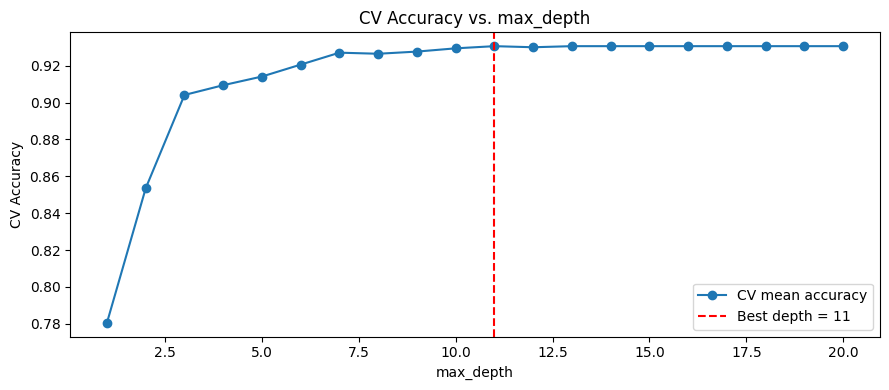

In [35]:
plt.figure(figsize=(9, 4))
plt.plot(list(depths), cv_means, marker='o', label='CV mean accuracy')

plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('CV Accuracy vs. max_depth')
plt.legend()
plt.tight_layout()
plt.show()

Then we can try that hyperparameter(max depth = 11) on the validation set.

In [36]:
best_clf = TreeClassifier(max_depth=best_depth, criterion='info_gain')
best_clf.fit(Xtrain, Ytrain)

Yguess   = best_clf.predict(Xtest)
test_acc = accuracy_score(Ytest, Yguess)

print(f"TreeClassifier (max_depth={best_depth}). Test set accuracy: {test_acc:.4f}")

TreeClassifier (max_depth=11). Test set accuracy: 0.9178


we got a 0.9178 accuracy on the validation set.

Finally we can visualize a drawing of a shallow tree, we decided to go with max_depth=4. We used the same functions to draw it as in the code provided.

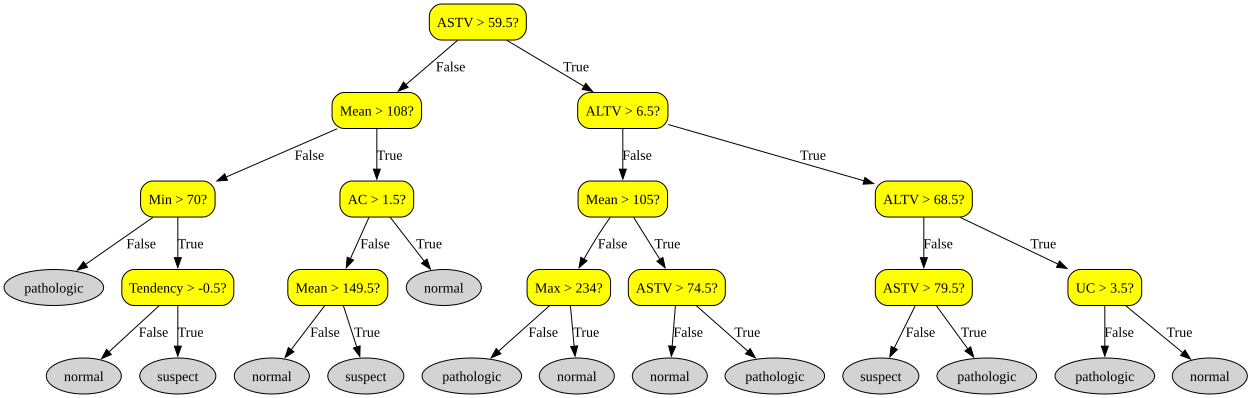

In [37]:
viz_clf = TreeClassifier(max_depth=4, criterion='info_gain')
viz_clf.fit(Xtrain, Ytrain)
viz_clf.draw_tree()

### Task 3: A regression example: predicting property prices

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Read the Excel file using Pandas.
alldata = pd.read_excel('Hemnet_data.xlsx')

# # Convert the timestamp string to an integer representing the year.
alldata['year'] = pd.DatetimeIndex(alldata['Sold Date']).year

# Convert 'yes' to 1 and 'no' to 0
alldata['Balcony'] = alldata['Balcony'].map({'Yes': 1, 'No': 0})
alldata['Patio'] = alldata['Patio'].map({'Yes': 1, 'No': 0})
alldata['Lift'] = alldata['Lift'].map({'Yes': 1, 'No': 0})

# Select the 12 input columns and the output column.
selected_columns = ['Final Price (kr)', 'year',  'Num of Room', 'Living Area (m²)', 'Balcony', 'Patio','Current Floor', 'Total Floor', 'Lift', 'Built Year', 'Fee (kr/month)', 'Operating Fee (kr/year)']
alldata = alldata[selected_columns]
alldata = alldata.dropna()

# Strip non-numeric characters and convert to float(i added extra)
for col in alldata.columns:
    alldata[col] = pd.to_numeric(
        alldata[col].astype(str).str.replace(r'[^\d.\-]', '', regex=True),
        errors='coerce'
    )
alldata = alldata.dropna()

# Shuffle.
alldata_shuffled = alldata.sample(frac=1.0, random_state=0)

# Separate the input and output columns.
X = alldata_shuffled.drop('Final Price (kr)', axis=1)
# For the output, we'll use the log of the sales price.
Y = alldata_shuffled['Final Price (kr)'].apply(np.log)

# Split into training and test sets.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)

#### Baseline: Dummy Regressor

In [39]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate

m1 = DummyRegressor()
scores = cross_validate(m1, Xtrain, Ytrain, scoring='neg_mean_squared_error')
print("DummyRegressor: ", -scores['test_score'].mean())

DummyRegressor:  0.34593721954567236


#### Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

r1 = LinearRegression()
scores = cross_validate(r1, Xtrain, Ytrain, scoring='neg_mean_squared_error')
print("LinearRegression: ", -scores['test_score'].mean())

LinearRegression:  0.2204405551756093


#### Ridge

In [41]:
from sklearn.linear_model import Ridge

r2 = Ridge()
scores = cross_validate(r2, Xtrain, Ytrain, scoring='neg_mean_squared_error')
print("Ridge: ", -scores['test_score'].mean())

Ridge:  0.22043967992163022


#### Decision Tree Regressor

In [42]:
from sklearn.tree import DecisionTreeRegressor

r4 = DecisionTreeRegressor(max_depth=5, random_state=0)
scores = cross_validate(r4, Xtrain, Ytrain, scoring='neg_mean_squared_error')
print("DecisionTreeRegressor: ", -scores['test_score'].mean())

DecisionTreeRegressor:  0.2020521914195466


#### Final evaluation on the test set

In [43]:
from sklearn.metrics import mean_squared_error

regr = DecisionTreeRegressor(max_depth=5, random_state=0)

regr.fit(Xtrain, Ytrain)
mean_squared_error(Ytest, regr.predict(Xtest))

0.19098565434231857

We tried three regression models: LinearRegression, Ridge and DecisionTreeRegressor. The selected model is DecisionTreeRegressor (max_depth=5), with a test set MSE of 0.1909.

### Task 4: Decision trees for regression

#### TreeRegressor implementation

In [44]:
from sklearn.base import RegressorMixin

class TreeRegressor(DecisionTree, RegressorMixin):

    def __init__(self, max_depth=10, var_threshold=1e-6):
        super().__init__(max_depth)
        self.var_threshold = var_threshold

    def get_default_value(self, Y):
        return float(np.mean(Y))

    def is_homogeneous(self, Y):
        return np.var(Y) < self.var_threshold

    def best_split(self, X, Y, feature):
        sorted_indices = np.argsort(X[:, feature])
        X_sorted = X[sorted_indices, feature]
        Y_sorted = Y[sorted_indices]

        n = len(Y)
        total_var = np.var(Y)
        sum_low = 0.0
        sum_sq_low = 0.0

        sum_total = np.sum(Y_sorted)
        sum_sq_total = np.sum(Y_sorted ** 2)

        best_score = -np.inf
        best_i = None

        for i in range(n - 1):
            y_i = Y_sorted[i]

            sum_low += y_i
            sum_sq_low += y_i ** 2

            n_low = i + 1
            n_high = n - n_low

            if X_sorted[i] == X_sorted[i + 1]:
                continue

            #variance
            var_low = (sum_sq_low / n_low) - (sum_low / n_low) ** 2
            
            sum_high = sum_total - sum_low
            sum_sq_high = sum_sq_total - sum_sq_low
            var_high = (sum_sq_high / n_high) - (sum_high / n_high) ** 2

            #variance reduction
            score = total_var - (n_low * var_low + n_high * var_high) / n

            if score > best_score:
                best_score = score
                best_i = i

        if best_i is None:
            return -np.inf, None, None

        split_point = 0.5 * (X_sorted[best_i] + X_sorted[best_i + 1])
        return best_score, feature, split_point

#### Sanity check

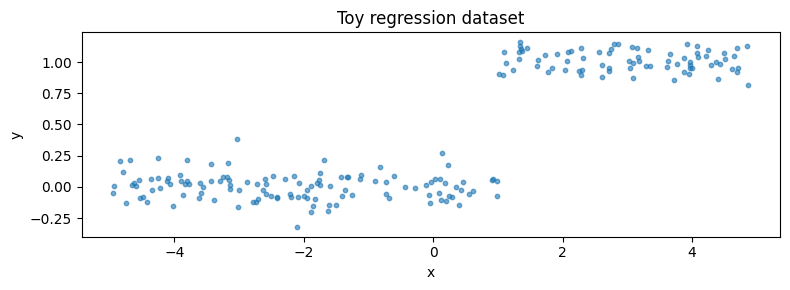

In [45]:
def make_some_data(n):
    rng = np.random.RandomState(42)
    x = rng.uniform(-5, 5, size=n)
    Y = (x > 1) + 0.1 * rng.normal(size=n)
    X = x.reshape(n, 1)
    return X, Y

X_toy, Y_toy = make_some_data(200)

plt.figure(figsize=(8, 3))
plt.scatter(X_toy[:, 0], Y_toy, s=10, alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy regression dataset')
plt.tight_layout()
plt.show()

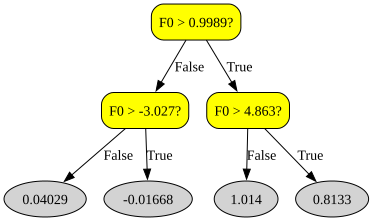

In [46]:
reg_toy = TreeRegressor(max_depth=2)
reg_toy.fit(X_toy, Y_toy)
reg_toy.draw_tree()

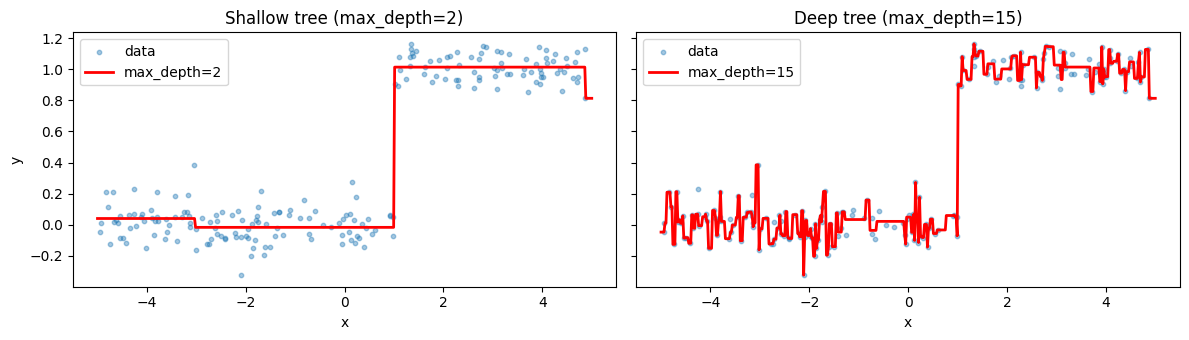

In [47]:
reg_deep = TreeRegressor(max_depth=15)
reg_deep.fit(X_toy, Y_toy)

X_grid = np.linspace(-5, 5, 500).reshape(-1, 1)
Y_pred_shallow = reg_toy.predict(X_grid)
Y_pred_deep = reg_deep.predict(X_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

axes[0].scatter(X_toy[:, 0], Y_toy, s=10, alpha=0.4, label='data')
axes[0].plot(X_grid[:, 0], Y_pred_shallow, color='red', lw=2, label='max_depth=2')
axes[0].set_title('Shallow tree (max_depth=2)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend()

axes[1].scatter(X_toy[:, 0], Y_toy, s=10, alpha=0.4, label='data')
axes[1].plot(X_grid[:, 0], Y_pred_deep, color='red', lw=2, label='max_depth=15')
axes[1].set_title('Deep tree (max_depth=15)')
axes[1].set_xlabel('x')
axes[1].legend()

plt.tight_layout()
plt.show()

The shallow tree (max_depth=2) correctly captures the step-function structure with a split near 1. The deep tree (max_depth=15) overfits a lot, it chases noise in the training data, producing a  zig-zag prediction that not generalizes well.

#### Predicting apartment prices

In [48]:
Xtrain_apt = Xtrain.to_numpy()
Xtest_apt  = Xtest.to_numpy()
Ytrain_apt = Ytrain.to_numpy()
Ytest_apt  = Ytest.to_numpy()
print(f"Training samples: {len(Xtrain_apt)}")
print(f"Test samples:     {len(Xtest_apt)}")

Training samples: 8851
Test samples:     2213


We selected the max_depth with the highest CV R² and evaluated on the held-out test set. The depth and scores are printed above.

In [49]:
from sklearn.metrics import r2_score

best_r2 = -np.inf
best_d  = None
for d in range(1, 13):
    reg = TreeRegressor(max_depth=d)
    scores = cross_val_score(reg, Xtrain_apt, Ytrain_apt, cv=5, scoring='r2')
    mean_r2 = scores.mean()
    print(f"max_depth={d:>2}  CV R²: {mean_r2:.4f} ± {scores.std():.4f}")
    if mean_r2 > best_r2:
        best_r2 = mean_r2
        best_d = d

print(f"\nBest max_depth: {best_d}  (CV R²: {best_r2:.4f})")

max_depth= 1  CV R²: 0.1257 ± 0.0224
max_depth= 2  CV R²: 0.2284 ± 0.0191
max_depth= 3  CV R²: 0.3022 ± 0.0152
max_depth= 4  CV R²: 0.3739 ± 0.0141
max_depth= 5  CV R²: 0.4153 ± 0.0176
max_depth= 6  CV R²: 0.4402 ± 0.0131
max_depth= 7  CV R²: 0.4569 ± 0.0061
max_depth= 8  CV R²: 0.4424 ± 0.0150
max_depth= 9  CV R²: 0.4351 ± 0.0116
max_depth=10  CV R²: 0.4116 ± 0.0154
max_depth=11  CV R²: 0.3900 ± 0.0146
max_depth=12  CV R²: 0.3546 ± 0.0146

Best max_depth: 7  (CV R²: 0.4569)


In [50]:
from sklearn.metrics import mean_squared_error

reg_final = TreeRegressor(max_depth=best_d)
reg_final.fit(Xtrain_apt, Ytrain_apt)
Ypred_apt = reg_final.predict(Xtest_apt)
test_r2  = r2_score(Ytest_apt, Ypred_apt)
test_mse = mean_squared_error(Ytest_apt, Ypred_apt)
print(f"TreeRegressor (max_depth={best_d}), Test R²: {test_r2:.4f}, Test MSE: {test_mse:.4f}")

TreeRegressor (max_depth=7), Test R²: 0.4869, Test MSE: 0.1727


#### Underfitting and overfitting

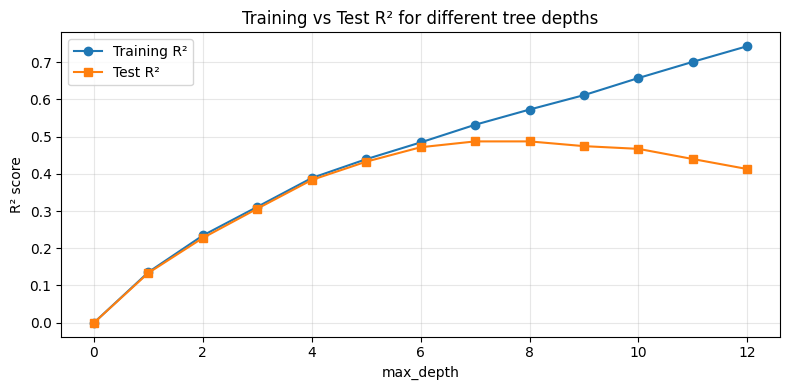

In [51]:
depths = range(0, 13)
train_scores = []
test_scores  = []

for d in depths:
    reg = TreeRegressor(max_depth=d)
    reg.fit(Xtrain_apt, Ytrain_apt)
    
    Ypred_train = reg.predict(Xtrain_apt)
    Ypred_test  = reg.predict(Xtest_apt)
    
    train_scores.append(r2_score(Ytrain_apt, Ypred_train))
    test_scores.append(r2_score(Ytest_apt, Ypred_test))

plt.figure(figsize=(8, 4))
plt.plot(list(depths), train_scores, 'o-', label='Training R²')
plt.plot(list(depths), test_scores,  's-', label='Test R²')
plt.xlabel('max_depth')
plt.ylabel('R² score')
plt.title('Training vs Test R² for different tree depths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

At low depths (0–2) both curves are low and close together. The model underfits because it is too simple. Both curves rise together up to depth 4, where the test R² peaks (0.42). Beyond that, training R² keeps climbing towards 0.83, but test R² declines, dropping to 0.30 at depth 12. This widening gap happens because the tree fits training noise that does not generalise. So the optimal depth is around 4.